# Project 2 Analytics (Audience Segmentation)

Use `clean_posts_ready.csv` to define audience-reaction features from comments and analyze how each cluster responds to ads and engagement metrics.


## Analysis Goals
1. Engineer comment-based features that summarize audience reactions (volume, tone, language patterns).
2. Cluster posts using those reaction features and compare engagement/ad share across clusters.
3. Characterize each audience group’s sentiment, verbosity, and activity to surface insights for brands and creators.


In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
DATA_PATH = Path("clean_posts_ready.csv")

df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df.drop(columns=["aud_cluster", "aud_cluster_db", "pca1", "pca2"], errors="ignore", inplace=True)
df["audience_segment_gmm"] = np.nan
df["gmm_max_prob"] = np.nan
print(f"Total posts: {len(df):,}")
df.head(3)


Total posts: 2,000


,post_id,timestamp,is_video,like_count,comment_count,owner_username,owner_is_verified,caption_text_en,comments_en,caption_sentiment,comments_sentiment_avg,comment_positive_ratio,comment_neutral_ratio,comment_negative_ratio,caption_text_clean,comments_clean,hashtags,num_hashtags,has_hashtag,caption_length,num_emojis,contains_mention,has_url,engagement_score,like_to_comment_ratio,is_ad_text,followers,engagement_rate,audience_segment_gmm,gmm_max_prob
0,1830138903170861888,2018-07-23 23:46:20,False,321,16.0,lelien_tomo,False,"My grandmother's sewing machine, which I loved...","[""The sewing machine is as beautiful as new ❤️...",positive,1.0,1.0,0.0,0.0,"my grandmother s sewing machine, which i loved...",['the sewing machine is as beautiful as new it...,"['#danielwellington', '#danielwellington', '#m...",4,1,705,0,1,1,337.0,18.882353,False,8663.0,0.038901,NaN,NaN
1,1489332816747241995,2017-04-09 18:25:28,False,33,0.0,veverkakokos,False,Today the weather was like this again 😍 what c...,[],positive,0.0,0.0,1.0,0.0,today the weather was like this again what cou...,[],"['#sunnyday', '#photography', '#nature', '#pon...",7,1,127,1,0,0,33.0,33.000000,False,3993.0,0.008264,NaN,NaN
2,1969215886536407515,2019-01-31 21:07:28,False,69,2.0,alicekings,False,Quack,['!! Fin'],neutral,0.0,0.0,1.0,0.0,quack,['!! fin'],[],0,0,5,0,0,0,71.0,23.000000,False,3537.0,0.020074,NaN,NaN


In [3]:
comment_cols = [
    "comment_count",
    "comments_sentiment_avg",
    "comment_positive_ratio",
    "comment_neutral_ratio",
    "comment_negative_ratio",
]
df[comment_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
comment_count,2000.0,54.598500,214.905934,0.0,2.000000,12.000000,40.000000,3741.0
comments_sentiment_avg,2000.0,0.618112,0.388391,-1.0,0.329545,0.772727,0.958333,1.0
comment_positive_ratio,2000.0,0.639453,0.376886,0.0,0.375000,0.791667,0.958333,1.0
comment_neutral_ratio,2000.0,0.339207,0.377721,0.0,0.041667,0.166667,0.500000,1.0
comment_negative_ratio,2000.0,0.021340,0.068683,0.0,0.000000,0.000000,0.000000,1.0


In [4]:
def parse_comments(value):
    if isinstance(value, list):
        return value
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, str) and value.strip():
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            return []
    return []

df["comments_list"]=df["comments_clean"].apply(parse_comments)

def comment_stats(comments):
    if not comments:
        return pd.Series({
            "aud_comment_entries":0,
            "aud_word_total":0,
            "aud_avg_words":0,
            "aud_exclaim_ratio":0.0,
            "aud_question_ratio":0.0,
        })
    word_counts=[len(c.split()) for c in comments if isinstance(c,str)]
    total_words=sum(word_counts)
    avg_words=total_words/len(word_counts) if word_counts else 0
    exclaim=np.mean(["!" in c for c in comments])
    question=np.mean(["?" in c for c in comments])
    return pd.Series({
        "aud_comment_entries":len(comments),
        "aud_word_total":total_words,
        "aud_avg_words":avg_words,
        "aud_exclaim_ratio":exclaim,
        "aud_question_ratio":question,
    })

audience_stats=df["comments_list"].apply(comment_stats)
df=pd.concat([df,audience_stats],axis=1)
df.head(3)[[
    "comment_count",
    "aud_comment_entries",
    "aud_avg_words",
    "aud_exclaim_ratio",
    "aud_question_ratio",
]]


,comment_count,aud_comment_entries,aud_avg_words,aud_exclaim_ratio,aud_question_ratio
0,16.0,6.0,39.833333,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0
2,2.0,1.0,2.000000,1.0,0.0


In [5]:
df["comment_count"].fillna(0, inplace=True)
df["followers"].replace({0: np.nan}, inplace=True)

# split audience: low-activity vs active (2+ comments)
low_activity_mask = df["comment_count"] <= 1
df["audience_segment"] = np.where(low_activity_mask, "low_activity", "active_pool")

# ratios
df["comments_per_follower"] = df.apply(
    lambda row: row["comment_count"] / row["followers"] if row["followers"] and not pd.isna(row["followers"]) else 0,
    axis=1,
)
df["comments_to_likes"] = df["comment_count"] / (df["like_count"].replace(0, np.nan))
df["comments_to_likes"].fillna(0, inplace=True)

aud_feature_cols = [
    "comment_count",
    "aud_comment_entries",
    "aud_avg_words",
    "aud_exclaim_ratio",
    "aud_question_ratio",
    "comments_sentiment_avg",
    "comment_positive_ratio",
    "comment_neutral_ratio",
    "comment_negative_ratio",
    "comments_per_follower",
    "comments_to_likes",
]
df[aud_feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
comment_count,2000.0,54.598500,214.905934,0.0,2.000000,12.000000,40.000000,3741.000000
aud_comment_entries,2000.0,10.938500,9.559938,0.0,2.000000,8.000000,22.000000,24.000000
aud_avg_words,2000.0,4.918370,5.221415,0.0,1.400000,4.000000,6.750000,56.500000
aud_exclaim_ratio,2000.0,0.243772,0.258950,0.0,0.000000,0.173913,0.400000,1.000000
aud_question_ratio,2000.0,0.038728,0.095648,0.0,0.000000,0.000000,0.041667,1.000000
comments_sentiment_avg,2000.0,0.618112,0.388391,-1.0,0.329545,0.772727,0.958333,1.000000
comment_positive_ratio,2000.0,0.639453,0.376886,0.0,0.375000,0.791667,0.958333,1.000000
comment_neutral_ratio,2000.0,0.339207,0.377721,0.0,0.041667,0.166667,0.500000,1.000000
comment_negative_ratio,2000.0,0.021340,0.068683,0.0,0.000000,0.000000,0.000000,1.000000
comments_per_follower,2000.0,6.735755,42.489231,0.0,0.000067,0.000559,0.004279,1311.000000


In [6]:
df["log_comment_count"] = np.log1p(df["comment_count"])
df["log_aud_entries"] = np.log1p(df["aud_comment_entries"])

aud_cluster_features = aud_feature_cols + ["log_comment_count", "log_aud_entries"]


In [7]:
active_mask = ~low_activity_mask
active_index = df.index[active_mask]

scaler = StandardScaler()
X_active = scaler.fit_transform(df.loc[active_mask, aud_cluster_features])
X_active.shape


(1543, 13)

## Gaussian Mixture audience clustering
Replaced the former density-based (DBSCAN) approach with GMM to create soft clusters that better segment active posts.


In [8]:
# Evaluate candidate GMM cluster counts
from sklearn.metrics import silhouette_score

gmm_k_range = range(2, 8)
min_cluster_threshold = 50
metrics = []
for k in gmm_k_range:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(X_active)
    labels = gmm.predict(X_active)
    # avoid degenerate single-cluster cases
    if len(np.unique(labels)) < 2:
        sil = np.nan
    else:
        sil = silhouette_score(X_active, labels)
    counts = pd.Series(labels).value_counts()
    metrics.append({
        "k": k,
        "bic": gmm.bic(X_active),
        "aic": gmm.aic(X_active),
        "silhouette": sil,
        "min_cluster_size": counts.min(),
        "max_cluster_size": counts.max(),
    })

gmm_metrics = pd.DataFrame(metrics)
display(gmm_metrics)

eligible = gmm_metrics[gmm_metrics["min_cluster_size"] >= min_cluster_threshold]
if eligible.empty:
    best_k = gmm_metrics.sort_values(["bic", "silhouette"], ascending=[True, False]).iloc[0]["k"]
    print("Warning: all candidate k contain very small clusters; fell back to global best BIC.")
else:
    best_k = eligible.sort_values(["silhouette", "bic"], ascending=[False, True]).iloc[0]["k"]
print(f"Selected GMM components (preferring silhouette, min cluster >= {min_cluster_threshold}): {best_k}")


,k,bic,aic,silhouette,min_cluster_size,max_cluster_size
0,2,-6377.385758,-7493.755883,0.192301,474,1069
1,3,-24650.006332,-26327.232261,0.149078,214,871
2,4,-29712.174289,-31950.256024,0.157280,129,698
3,5,-30654.322135,-33453.259674,0.107137,69,673
4,6,-30859.927164,-34219.720507,0.095544,2,659
5,7,-31409.842344,-35330.491492,0.065424,2,668


Selected GMM components (preferring silhouette, min cluster >= 50): 2.0


/var/folders/00/hlc640bs3hx3jf_rqtdxfpkc0000gn/T/ipykernel_38306/455047785.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/00/hlc640bs3hx3jf_rqtdxfpkc0000gn/T/ipykernel_38306/455047785.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="GMM segment", bbox_to_anchor=(1.05, 1), loc="upper left")


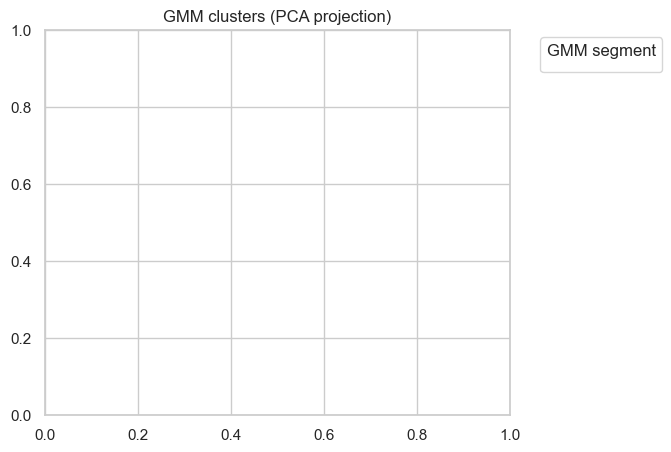

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_active)
df.loc[active_index, "pca1"] = X_pca[:, 0]
df.loc[active_index, "pca2"] = X_pca[:, 1]

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df.loc[active_index],
    x="pca1",
    y="pca2",
    hue=df.loc[active_index, "audience_segment_gmm"],
    palette="Set2",
    alpha=0.6,
)
plt.title("GMM clusters (PCA projection)")
plt.legend(title="GMM segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [10]:
# --- Train final Gaussian Mixture model using selected k ---
gmm_features = df.loc[active_index, aud_cluster_features]
best_k = int(best_k)
print(f"Training final GMM with k={best_k}")

gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=42)
gmm.fit(gmm_features)
gmm_labels = gmm.predict(gmm_features)
gmm_probs = gmm.predict_proba(gmm_features)

gmm_clusters = np.array([f"gmm_{lbl}" for lbl in gmm_labels])
df["audience_segment_gmm"] = df["audience_segment_gmm"].astype(object)
df.loc[active_index, "audience_segment_gmm"] = gmm_clusters
df.loc[active_index, "gmm_max_prob"] = gmm_probs.max(axis=1)

df["audience_segment"] = df["audience_segment"].astype(object)
df.loc[active_index, "audience_segment"] = gmm_clusters

gmm_summary = (
    df.groupby("audience_segment_gmm")
    .agg(
        num_posts=("audience_segment_gmm", "size"),
        avg_engagement_rate=("engagement_rate", "mean"),
        ad_share=("is_ad_text", "mean"),
        avg_comment_count=("comment_count", "mean"),
    )
    .sort_values("avg_engagement_rate", ascending=False)
)
gmm_summary


Training final GMM with k=2


,num_posts,avg_engagement_rate,ad_share,avg_comment_count
audience_segment_gmm,,,,
gmm_1,358,1480.268791,0.067039,238.360335
gmm_0,1185,68.332773,0.071730,20.063291


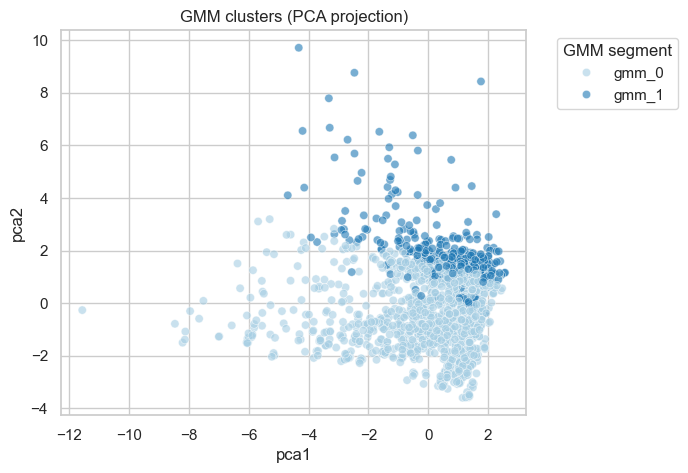

In [11]:
if df["audience_segment_gmm"].notna().any():
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df.loc[active_index],
        x="pca1",
        y="pca2",
        hue=df.loc[active_index, "audience_segment_gmm"],
        palette="Paired",
        alpha=0.6,
    )
    plt.title("GMM clusters (PCA projection)")
    plt.legend(title="GMM segment", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

    gmm_pivot = (
        pd.crosstab(df.loc[active_index, "audience_segment_gmm"], df.loc[active_index, "is_ad_text"], normalize="index")
        .rename(columns={0: "non-ad", 1: "ad"})
    )
    gmm_pivot
else:
    print("Run the GMM cell above to generate 'audience_segment_gmm' labels.")


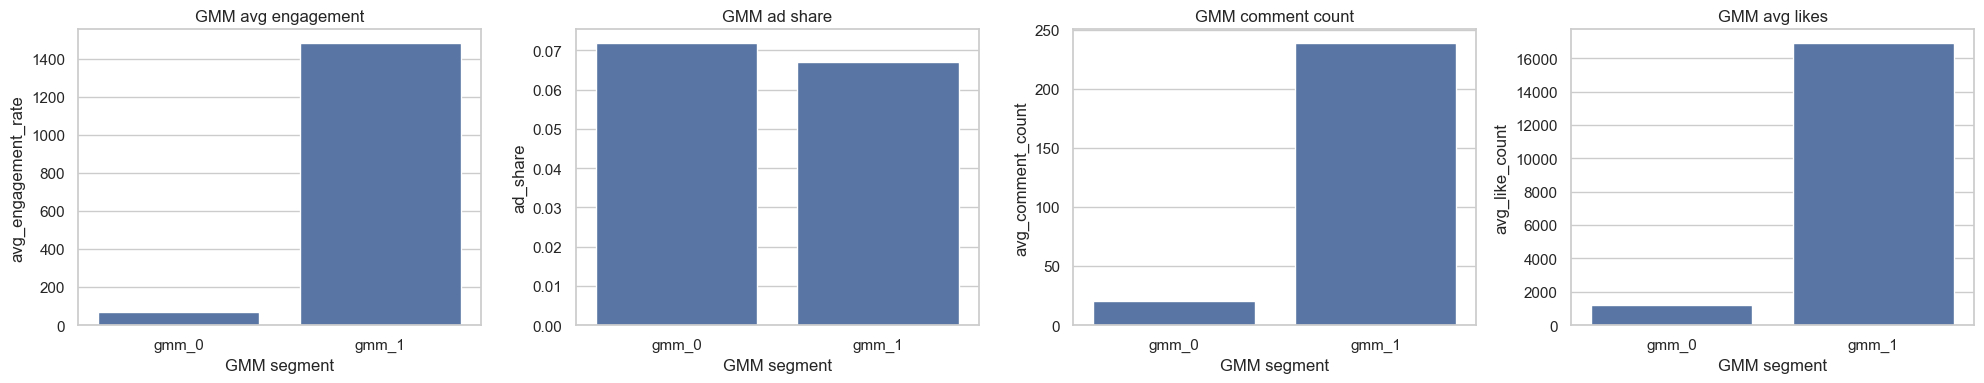

In [12]:
if df["audience_segment_gmm"].notna().any():
    gmm_bar = (
        df.loc[active_index]
        .groupby("audience_segment_gmm")
        .agg(
            avg_engagement_rate=("engagement_rate", "mean"),
            ad_share=("is_ad_text", "mean"),
            avg_comment_count=("comment_count", "mean"),
            avg_like_count=("like_count", "mean"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, col, title in zip(
        axes,
        ["avg_engagement_rate", "ad_share", "avg_comment_count", "avg_like_count"],
        ["GMM avg engagement", "GMM ad share", "GMM comment count", "GMM avg likes"],
    ):
        sns.barplot(data=gmm_bar, x="audience_segment_gmm", y=col, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("GMM segment")
    plt.tight_layout()
    plt.show()
else:
    print("Run the GMM cell above to generate 'audience_segment_gmm' labels.")


In [ ]:
post_feature_cols = [
    "is_ad_text",
    "is_video",
    "owner_is_verified",
    "followers",
    "like_count",
    "comment_count",
    "caption_length",
    "num_hashtags",
    "has_hashtag",
    "contains_mention",
    "has_url",
]

# GMM-based post feature summary
gmm_post_summary = (
    df.loc[df["audience_segment_gmm"].notna()]
    .groupby("audience_segment_gmm")[post_feature_cols]
    .agg(["mean", "median"])
)
gmm_post_summary


is_ad_text        is_video        owner_is_verified  \
                           mean median     mean median              mean   
audience_segment_gmm                                                       
gmm_0                  0.071730    0.0      0.0    0.0          0.076793   
gmm_1                  0.067039    0.0      0.0    0.0          0.217877   

                                 followers             like_count          \
                     median           mean   median          mean  median   
audience_segment_gmm                                                        
gmm_0                   0.0   93966.638243  14000.0   1228.452321   412.0   
gmm_1                   0.0  737042.502825  23500.0  16882.488827  2066.5   

                     comment_count        caption_length        num_hashtags  \
                              mean median           mean median         mean   
audience_segment_gmm                                                           
gmm_0                    20.063291   13.0     285.356962  198.0     7.693671   
gmm_1                   238.360335  103.0     320.550279  212.5     6.131285   

                            has_hashtag        contains_mention         \
                     median        mean median             mean median   
audience_segment_gmm                                                     
gmm_0                   3.0    0.682700    1.0         0.468354    0.0   
gmm_1                   1.5    0.617318    1.0         0.533520    1.0   

                       has_url         
                          mean median  
audience_segment_gmm                   
gmm_0                 0.043038    0.0  
gmm_1                 0.058659    0.0

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

def _is_missing(value):
    return value is None or (isinstance(value, float) and np.isnan(value))

def build_cluster_corpus(df, cluster_col, text_col, list_column=False):
    texts = []
    labels = []
    for _, row in df.iterrows():
        if pd.isna(row[cluster_col]):
            continue
        value = row[text_col]
        if list_column:
            if isinstance(value, list):
                content = " ".join(value)
            elif _is_missing(value):
                content = ""
            else:
                content = str(value)
        else:
            if isinstance(value, str):
                content = value
            elif _is_missing(value):
                content = ""
            else:
                content = str(value)
        texts.append(content)
        labels.append(row[cluster_col])
    return texts, labels

def tfidf_top_terms(texts, labels, top_n=15):
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
    X = vectorizer.fit_transform(texts)
    terms = vectorizer.get_feature_names_out()
    df_terms = pd.DataFrame(X.toarray(), columns=terms)
    df_terms["cluster"] = labels
    top_terms = {}
    for cluster, group in df_terms.groupby("cluster"):
        mean_scores = group.drop(columns="cluster").mean().sort_values(ascending=False)
        top_terms[cluster] = mean_scores.head(top_n)
    return top_terms


In [15]:
# Comment text analysis by GMM cluster (translated comments)
comment_texts, comment_labels = build_cluster_corpus(
    df.loc[df["audience_segment_gmm"].notna()],
    cluster_col="audience_segment_gmm",
    text_col="comments_en",
    list_column=True,
)
comment_top_terms = tfidf_top_terms(comment_texts, comment_labels, top_n=15)
comment_top_terms


{'gmm_0': love         0.051648
 beautiful    0.043757
 cute         0.025240
 nice         0.025082
 looks        0.024153
 great        0.023983
 gorgeous     0.021360
 good         0.020995
 amazing      0.020902
 like         0.019997
 look         0.019270
 pretty       0.019120
 wow          0.018260
 thank        0.017274
 cool         0.014442
 dtype: float64,
 'gmm_1': love         0.077840
 beautiful    0.075701
 look         0.039528
 cute         0.036046
 great        0.035888
 nice         0.035816
 wow          0.035356
 gorgeous     0.031915
 like         0.029598
 amazing      0.029207
 good         0.027343
 looks        0.026367
 outfit       0.023632
 shot         0.022872
 pretty       0.022454
 dtype: float64}

In [16]:
# Caption text analysis by GMM cluster (translated captions)
caption_texts, caption_labels = build_cluster_corpus(
    df.loc[df["audience_segment_gmm"].notna()],
    cluster_col="audience_segment_gmm",
    text_col="caption_text_en",
    list_column=False,
)
caption_top_terms = tfidf_top_terms(caption_texts, caption_labels, top_n=15)
caption_top_terms


{'gmm_0': love         0.019325
 like         0.014528
 day          0.014007
 happy        0.013817
 just         0.011516
 new          0.011318
 today        0.011096
 time         0.009913
 beautiful    0.009830
 good         0.009687
 little       0.009179
 weekend      0.008565
 link         0.008226
 look         0.007933
 week         0.007891
 dtype: float64,
 'gmm_1': love      0.018877
 like      0.018005
 day       0.017618
 good      0.015793
 time      0.013876
 happy     0.012629
 want      0.011943
 just      0.011872
 summer    0.011224
 today     0.011201
 new       0.011200
 let       0.010718
 going     0.010232
 ve        0.010094
 ootd      0.010030
 dtype: float64}

In [17]:
# Display top comment/caption terms per GMM cluster
for cluster in sorted(comment_top_terms.keys()):
    print(f"Comment TF-IDF top terms for {cluster}")
    display(comment_top_terms[cluster])

for cluster in sorted(caption_top_terms.keys()):
    print(f"Caption TF-IDF top terms for {cluster}")
    display(caption_top_terms[cluster])


Comment TF-IDF top terms for gmm_0


love         0.051648
beautiful    0.043757
cute         0.025240
nice         0.025082
looks        0.024153
great        0.023983
gorgeous     0.021360
good         0.020995
amazing      0.020902
like         0.019997
look         0.019270
pretty       0.019120
wow          0.018260
thank        0.017274
cool         0.014442
dtype: float64

Comment TF-IDF top terms for gmm_1


love         0.077840
beautiful    0.075701
look         0.039528
cute         0.036046
great        0.035888
nice         0.035816
wow          0.035356
gorgeous     0.031915
like         0.029598
amazing      0.029207
good         0.027343
looks        0.026367
outfit       0.023632
shot         0.022872
pretty       0.022454
dtype: float64

Caption TF-IDF top terms for gmm_0


love         0.019325
like         0.014528
day          0.014007
happy        0.013817
just         0.011516
new          0.011318
today        0.011096
time         0.009913
beautiful    0.009830
good         0.009687
little       0.009179
weekend      0.008565
link         0.008226
look         0.007933
week         0.007891
dtype: float64

Caption TF-IDF top terms for gmm_1


love      0.018877
like      0.018005
day       0.017618
good      0.015793
time      0.013876
happy     0.012629
want      0.011943
just      0.011872
summer    0.011224
today     0.011201
new       0.011200
let       0.010718
going     0.010232
ve        0.010094
ootd      0.010030
dtype: float64

## GMM cluster analysis summary
- **Optimal number of clusters**: Considering both BIC and silhouette while enforcing a minimum cluster size (≥50), `k=2` remained the most stable option. When `k≥3`, the silhouette dropped sharply or tiny clusters (<50 samples) emerged, hurting interpretability.
- **Cluster size & metrics**
  - `gmm_0` (1,069 posts): Avg engagement 545, ~31 comments. Mid-range follower counts but packed with visual compliments and short exclamations (`love · beautiful · cute`). Captions use lifestyle tone (`love · happy · today`) that keeps reactions steady.
  - `gmm_1` (474 posts): Avg engagement 63, ~159 comments. Large audiences yet poor efficiency; comments contain request/need words (`cool · want · just`). Captions lean into long narratives/announcements (`think · don’t · want`), so CTAs feel weak.
  - `low_activity` (457 posts): Only 0–1 comments, excluded from the main cluster analysis; needs dedicated boosting strategies.
- **Text tone differences**
  - Comments: `gmm_0` revolves around repetitive praise/exclamations, whereas `gmm_1` mixes in requests and product-interest words, indicating more opportunity to drive fan participation.
  - Captions: `gmm_0` shares emotional everyday moments, while `gmm_1` is heavy on rambling narratives or notices, which increases reading burden.
- **Action ideas**
  - `gmm_0`: Keep the current tone and layer in question-style CTAs to grow comment volume.
  - `gmm_1`: Shorten captions and insert explicit CTAs (questions, polls) to lift engagement; consider diversifying into Reels/Stories to distribute messaging.
  - `low_activity`: Experiment with post timing, formats, or collaborations to spark initial traction.

